In [1]:
import random
from typing import TypedDict, NotRequired, TypeVar, Generic
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from IPython.display import Image, display
from abc import ABC, abstractmethod

S = TypeVar("S")

In [2]:
class State(TypedDict):
    input: int
    output: NotRequired[int]

In [3]:
class BaseNode(ABC, Generic[S]):
    @abstractmethod
    def run(self, state: S) -> dict:
        ...

    def __call__(self, state: S) -> dict:
        return self.run(state)

class NodeFactory:
    _registry: dict[str, type[BaseNode]] = {}

    @classmethod
    def register(cls, name: str):
        def decorator(node_cls: type[BaseNode]):
            cls._registry[name] = node_cls
            return node_cls
        return decorator

    @classmethod
    def create(cls, name: str, **kwargs) -> BaseNode:
        if name not in cls._registry:
            raise ValueError(f"Node '{name}' not registered")
        return cls._registry[name](**kwargs)

In [4]:
@NodeFactory.register("node_a")
class NodeA(BaseNode[State]):
    def run(self, state: State) -> dict:
        offset = random.randint(1, 10)
        output = state["input"] + offset
        print(f"Node A: input={state['input']}, offset={offset}, output={output}")
        return {"output": output}

node_a = NodeFactory.create("node_a")

In [5]:
@NodeFactory.register("node_b")
class NodeB(BaseNode[State]):
    def run(self, state: State) -> dict:
        offset = random.randint(1, 10)
        current = state.get("output", 0)
        output = current + offset
        print(f"Node B: input={current}, offset={offset}, output={output}")
        return {"output": output}

node_b = NodeFactory.create("node_b")

In [6]:
workflow = StateGraph(state_schema=State)

In [7]:
workflow.add_node("A", node_a)
workflow.add_node("B", node_b)

In [8]:
workflow.add_edge(START, "A")
workflow.add_edge("A", "B")
workflow.add_edge("B", END)

graph = workflow.compile()

display(
    Image(graph.get_graph().draw_mermaid_png())
)

ValueError: Failed to reach https://mermaid.ink API while trying to render your graph after 1 retries. To resolve this issue:
1. Check your internet connection and try again
2. Try with higher retry settings: `draw_mermaid_png(..., max_retries=5, retry_delay=2.0)`
3. Use the Pyppeteer rendering method which will render your graph locally in a browser: `draw_mermaid_png(..., draw_method=MermaidDrawMethod.PYPPETEER)`

In [ ]:
graph.invoke(input = {'input':5})

Node A: input=5, offset=9, output=14
Node B: input=14, offset=1, output=15


{'input': 5, 'output': 15}

In [ ]:
from dotenv import load_dotenv
load_dotenv()
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.0,
)

In [ ]:
class State2(TypedDict):
    question: str
    response: NotRequired[str]

@NodeFactory.register("model_node")
class ModelNode(BaseNode[State2]):
    def __init__(self, llm: ChatOpenAI):
        self.llm = llm

    def run(self, state: State2) -> dict:
        response = self.llm.invoke([
            SystemMessage("You're a Pokémon specialist"),
            HumanMessage(state["question"])
        ])
        return {"response": response.content}

model_node = NodeFactory.create("model_node", llm=llm)

In [ ]:
workflow2 = StateGraph(State2)

In [ ]:
workflow2.add_node("model", model_node)
workflow2.add_edge(START, "model")
workflow2.add_edge("model", END)
graph2 = workflow2.compile()

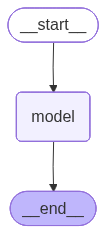

In [ ]:
display(
    Image(
        graph2.get_graph().draw_mermaid_png()
    )
)

result = graph2.invoke(input={"question": "What is the best Pokémon?"})

In [ ]:
result

{'question': 'What is the best Pokémon?',
 'response': 'The concept of the "best" Pokémon can vary greatly depending on the context, such as competitive battling, in-game performance, personal preference, or specific roles in a team. \n\nIn competitive battling, Pokémon like Arceus, Mega Rayquaza, and Mewtwo are often considered top-tier due to their high stats, versatile movepools, and ability to fit into various strategies. \n\nFor in-game playthroughs, Pokémon like Gardevoir, Charizard, or Lucario are popular choices due to their strong stats and useful typings.\n\nUltimately, the "best" Pokémon is subjective and can depend on individual playstyle and preferences. What do you have in mind for your criteria?'}